# Introduction to Black-Scholes and Implied Volatility

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Exploratory Data Analysis


Given our data is from yfinance, we can assume that its own implied volatility is not always correctly calculated. This is due to options being extremely OTM or ITM. Such options will break our implied volatility calculator, so we must first decide what to rid. 

In [15]:
SNAPSHOT = Path("../options-project/data/raw/spx_2026-07-10.parquet")
df = pd.read_parquet(SNAPSHOT)

In [ ]:
# Derived columns used throughout 
df["moneyness"] = df["K"] / df["S"]  # K/S: 1.0 = ATM
df["spread"] = df["ask"] - df["bid"]
df["rel_spread"] = df["spread"] / df["mid"].replace(0, np.nan)

In [27]:
# Summary of data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18783 entries, 0 to 18782
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   snapshot_date  18783 non-null  datetime64[ns]     
 1   snapshot_ts    18783 non-null  datetime64[us, UTC]
 2   option_type    18783 non-null  object             
 3   expiration     18783 non-null  datetime64[ns]     
 4   T              18783 non-null  float64            
 5   K              18783 non-null  float64            
 6   bid            18782 non-null  float64            
 7   ask            18783 non-null  float64            
 8   mid            18782 non-null  float64            
 9   volume         17306 non-null  float64            
 10  open_interest  18755 non-null  float64            
 11  S              18783 non-null  float64            
 12  r              18783 non-null  float64            
 13  iv_yfinance    18783 non-null  float64        

In [29]:
# Numerical Summary
print("\n ----- Numeric Summary -----")
print(df[["T", "K", "bid", "ask", "mid", "volume",
          "open_interest", "rel_spread", "moneyness"]].describe())


 ----- Numeric Summary -----
                  T             K           bid           ask           mid  \
count  18783.000000  18783.000000  18782.000000  18783.000000  18782.000000   
mean       0.434982   6858.750732    420.759813    423.754895    422.268634   
std        0.725061   1519.512126    838.038672    845.031340    840.046003   
min        0.000000    200.000000      0.000000      0.000000      0.000000   
25%        0.052055   6330.000000     11.300000     11.400000     11.450000   
50%        0.191781   7180.000000    103.950000    104.800000    104.875000   
75%        0.517808   7605.000000    435.400000    438.750000    438.337500   
max        5.446575  20000.000000   8156.000000   8456.000000   8306.000000   

              volume  open_interest    rel_spread     moneyness  
count   17306.000000   18755.000000  18647.000000  18783.000000  
mean      219.481220     954.341562      0.126875      0.905251  
std      3266.599809    5666.537065      0.400238      0.200

In [39]:
print("\n ----- Data Quality -----")
print(f"bid <= 0           : {(df['bid'] <= 0).sum()} rows")
print(f"bid > ask (crossed): {(df['bid'] > df['ask']).sum()} rows")
print(f"volume is NaN      : {df['volume'].isna().sum()} rows")
print(f"open_interest == 0 : {(df['open_interest'] == 0).sum()} rows")
print(f"rel_spread > 0.5   : {(df['rel_spread'] > 0.5).sum()} rows")



 ----- Data Quality -----
bid <= 0           : 806 rows
bid > ask (crossed): 23 rows
volume is NaN      : 1477 rows
open_interest == 0 : 1046 rows
rel_spread > 0.5   : 1230 rows


As seen above, there are many rows of data that we cannot use, as it will interfer with our calculations of IV. We will have to choose an appropriate level in filtering to determine what data is usable. We will create plots to identify the cutoff points. 


Saved figure to figures/diagnostics_spx_2026-07-10.png


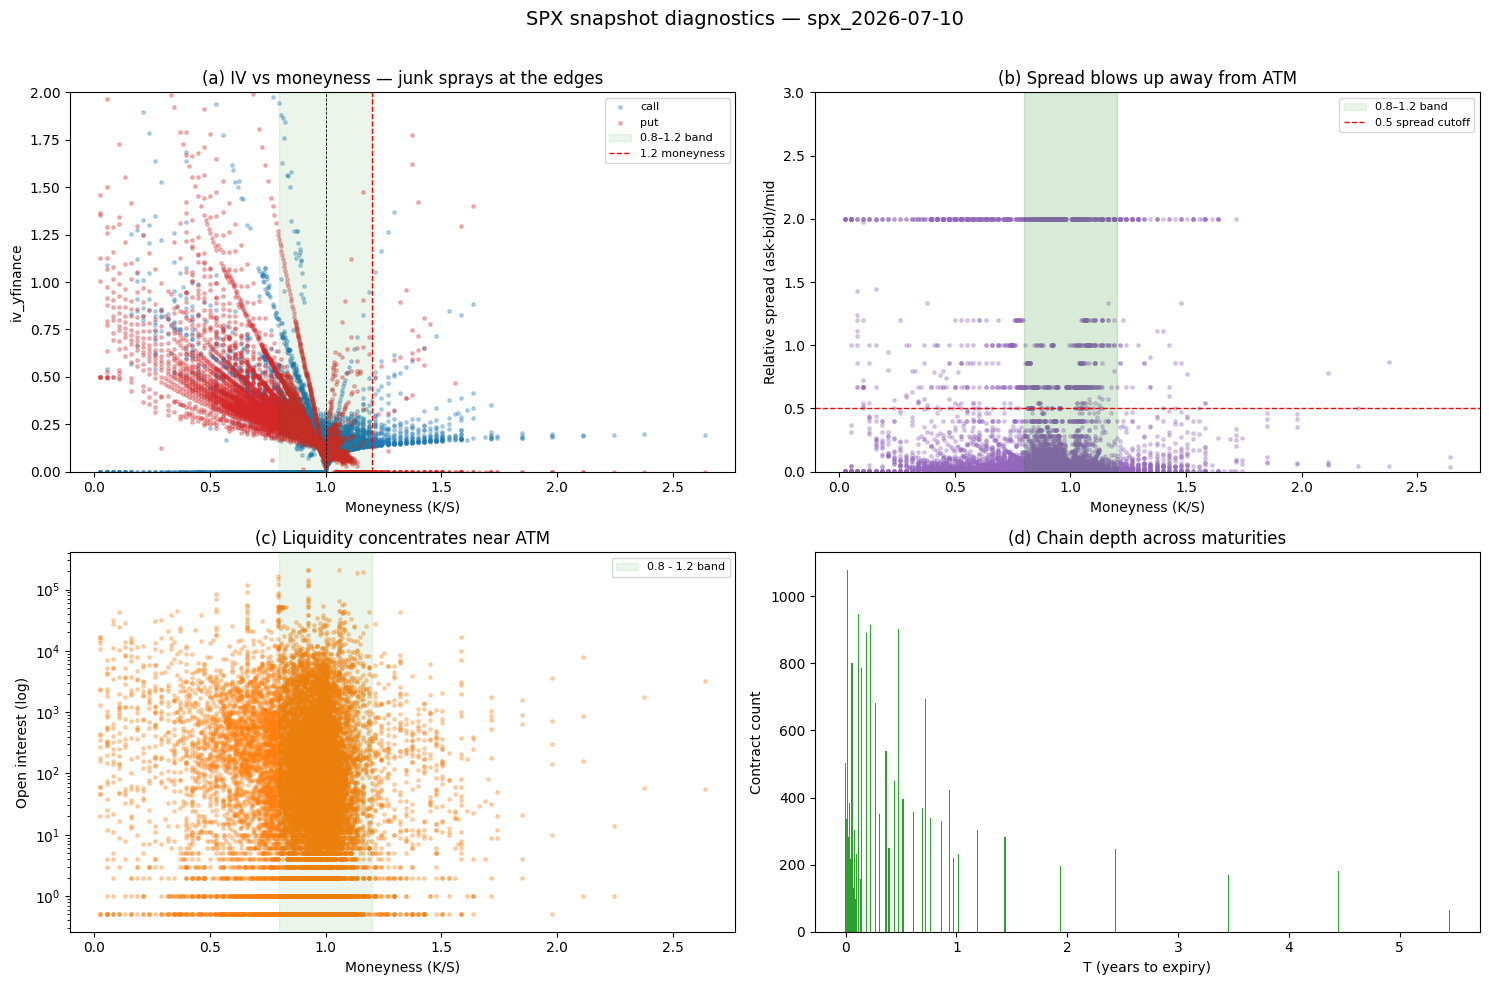

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"SPX snapshot diagnostics — {SNAPSHOT.stem}", fontsize=14)

# (a) yfinance IV vs moneyness 
ax = axes[0, 0]
for opt, color in [("call", "tab:blue"), ("put", "tab:red")]:
    sub = df[df["option_type"] == opt]
    ax.scatter(sub["moneyness"], sub["iv_yfinance"],
               s=6, alpha=0.3, color=color, label=opt)
ax.axvspan(0.80, 1.20, color="green", alpha=0.08, label="0.8–1.2 band")
ax.axvline(1.0, color="k", lw=0.6, ls="--")
ax.axvline(1.2, color="red", lw=1, ls="--", label="1.2 moneyness")
ax.set(xlabel="Moneyness (K/S)", ylabel="iv_yfinance",
       title="(a) IV vs moneyness — junk sprays at the edges")
ax.set_ylim(0, 2.0)  # clip the absurd values to see structure
ax.legend(fontsize=8)

# (b) Relative spread vs moneyness 
ax = axes[0, 1]
ax.scatter(df["moneyness"], df["rel_spread"], s=6, alpha=0.3, color="tab:purple")
ax.axvspan(0.80, 1.20, color="green", alpha=0.08, label="0.8–1.2 band")
ax.axhline(0.5, color="red", lw=1, ls="--", label="0.5 spread cutoff")
ax.axvspan(0.80, 1.20, color="green", alpha=0.08)
ax.set(xlabel="Moneyness (K/S)", ylabel="Relative spread (ask-bid)/mid",
       title="(b) Spread blows up away from ATM")
ax.set_ylim(0, 3)
ax.legend(fontsize=8)

# (c) Liquidity: open interest by moneyness (log scale)
ax = axes[1, 0]
ax.scatter(df["moneyness"], df["open_interest"].clip(lower=0.5),
           s=6, alpha=0.3, color="tab:orange")
ax.set_yscale("log")
ax.axvspan(0.80, 1.20, color="green", alpha=0.08, label="0.8 - 1.2 band")
ax.legend(fontsize=8, loc="upper right")  
ax.set(xlabel="Moneyness (K/S)", ylabel="Open interest (log)",
       title="(c) Liquidity concentrates near ATM")

# (d) Contracts per expiry 
ax = axes[1, 1]
counts = df.groupby("T").size()
ax.bar(counts.index, counts.values, width=0.01, color="tab:green")
ax.set(xlabel="T (years to expiry)", ylabel="Contract count",
       title="(d) Chain depth across maturities")

plt.tight_layout(rect=[0, 0, 1, 0.97])
out = Path("figures") / f"diagnostics_{SNAPSHOT.stem}.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=120)
print(f"\nSaved figure to {out}")
plt.show()

From the following plots, we can observe that the data needs to be cleaned and we must choose an optimal range for the filtering process. By looking at plot (a), we see that there's a real, clean smile structure. In the ATM region, the IVs converge into a tight, orderly band around 0.15–0.25 IV, which is near where Hull's textbook mentioned the smile to be located. We notice that around ~0.8 and ~1.2 Moneyness, the smile flares upwards. This is due to the calculations of IV being inaccurate as Vega approaches zero. In other words, the calls or deep ITM and the puts are deep OTM. Making them not idea for IV calculation.
